In [11]:
import os
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [12]:
class ImageIO:
    def __init__(self, device):
        self.device = device

    def load(self, path, max_size):
        img = Image.open(path).convert("RGB")

        # Redimensionado manteniendo aspect ratio
        w, h = img.size
        scale = min(max_size / max(w, h), 1.0)
        nw, nh = int(w * scale), int(h * scale)

        # Transformaciones estándar
        trans = transforms.Compose([
            transforms.Resize((720, 1280)),
            transforms.ToTensor()
        ])

        # Se agrega batch dimension y se mueve a GPU
        x = trans(img).unsqueeze(0).to(self.device)
        return x

    def to_pil(self, x):
        x = x.detach().clamp(0, 1).cpu().squeeze(0)
        return transforms.ToPILImage()(x)

    def save(self, x, path):
        self.to_pil(x).save(path)
        return path

    def show_triplet(self, content, style, out, figsize):
        imgs = [self.to_pil(content), self.to_pil(style), self.to_pil(out)]
        titles = ["Contenido", "Estilo", "Salida"]

        plt.figure(figsize=figsize)
        for i, im in enumerate(imgs, 1):
            plt.subplot(1, 3, i)
            plt.imshow(im)
            plt.title(titles[i - 1])
            plt.axis("off")
        plt.show()


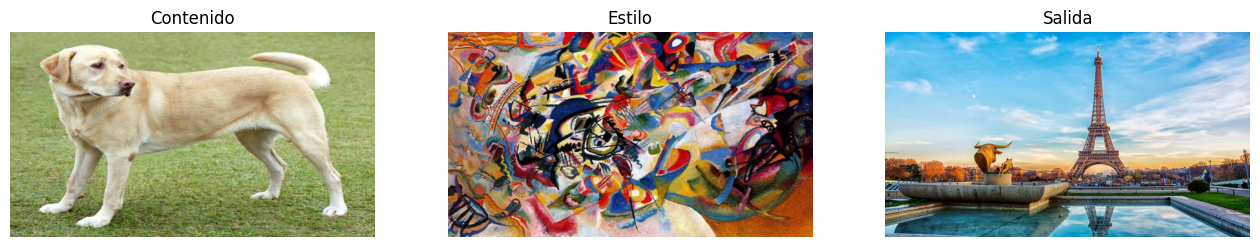

In [13]:
io = ImageIO(device)
content_path = "/content/YellowLabradorLooking_new.jpg"
style_path = "/content/Vassily_Kandinsky,_1913_-_Composition_7.jpg"
custom_path = "/content/torre_eiffel.jpg"

content_img = io.load(content_path, max_size=768)
style_img = io.load(style_path, max_size=768)
custom_img = io.load(custom_path, max_size=768)

io.show_triplet(content_img, style_img, custom_img, (16, 5))

In [14]:
class Normalization(nn.Module):
    """
    Normalización estándar ImageNet.
    Requerida porque VGG fue entrenada con estos valores.
    """
    def __init__(self, mean: List[float], std: List[float]):
        super().__init__()
        mean = torch.tensor(mean).view(1, 3, 1, 1)
        std = torch.tensor(std).view(1, 3, 1, 1)
        self.register_buffer("mean", mean)
        self.register_buffer("std", std)

    def forward(self, x):
        return (x - self.mean) / self.std


class GramMatrix(nn.Module):
    """
    Implementación de la matriz de Gram.
    Captura correlaciones entre mapas de características.
    """
    def forward(self, x: torch.Tensor):
        b, c, h, w = x.shape
        f = x.view(b, c, h * w)
        g = torch.bmm(f, f.transpose(1, 2))
        return g / (c * h * w)


class ContentLoss(nn.Module):
    """
    Pérdida de contenido (MSE entre features).
    """
    def __init__(self, target: torch.Tensor, weight: float = 1.0):
        super().__init__()
        self.target = target.detach()
        self.weight = weight

    def forward(self, input_feat: torch.Tensor) -> torch.Tensor:
        return self.weight * F.mse_loss(input_feat, self.target)


class StyleLoss(nn.Module):
    """
    Pérdida de estilo basada en Gram matrices.
    """
    def __init__(self, target_feat: torch.Tensor, weight: float = 1.0):
        super().__init__()
        self.gram = GramMatrix()
        self.target = self.gram(target_feat).detach()
        self.weight = weight

    def forward(self, input_feat):
        g = self.gram(input_feat)
        return self.weight * F.mse_loss(g, self.target)


class TotalVariationLoss(nn.Module):
    """
    Regularización TV para suavizar la imagen.
    """
    def __init__(self, weight: float = 1e-6):
        super().__init__()
        self.weight = weight

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        tv_h = torch.mean(torch.abs(x[:, :, :, :-1] - x[:, :, :, 1:]))
        tv_v = torch.mean(torch.abs(x[:, :, :-1, :] - x[:, :, 1:, :]))
        return self.weight * (tv_h + tv_v)


In [15]:
@dataclass
class VGGConfig:
    """
    Configuración de capas de contenido y estilo.
    """
    content_layers: List[str]
    style_layers: List[str]
    use_avg_pool: bool = True


class VGGFeatureExtractor(nn.Module):
    """
    Wrapper de VGG19 para extraer features intermedios.
    """
    def __init__(self, config: VGGConfig):
        super().__init__()

        # VGG19 preentrenada
        vgg = models.vgg19(weights=models.VGG19_Weights.DEFAULT).features.eval()

        # Reemplaza MaxPool por AvgPool como se recomienda en el paper
        if config.use_avg_pool:
            for i, layer in enumerate(vgg):
                if isinstance(layer, nn.MaxPool2d):
                    vgg[i] = nn.AvgPool2d(kernel_size=2, stride=2)

        # Congelamos pesos
        for p in vgg.parameters():
            p.requires_grad = False

        self.vgg = vgg
        self.config = config

    def forward(self, x: torch.Tensor) -> Dict[str, torch.Tensor]:
        """
        Retorna un diccionario con los features requeridos.
        """
        feats = {}
        for name, layer in self.vgg._modules.items():
            x = layer(x)
            if name in self.config.content_layers or name in self.config.style_layers:
                feats[name] = x
        return feats


In [16]:
cfg = VGGConfig(
    content_layers=["21"],
    style_layers=["0", "5", "10", "19", "28"],
    use_avg_pool=True
)

extractor = VGGFeatureExtractor(cfg).to(device).eval()

norm = Normalization(
    mean=[0.485, 0.456, 0.406],
    std=[0.229, 0.224, 0.225]
).to(device).eval()


In [17]:
@dataclass
class NSTConfig:
    """
    Hiperparámetros del algoritmo NST.
    """
    content_weight: float = 1.0
    style_weight: float = 1e4
    tv_weight: float = 1e-6
    steps: int = 400
    lr: float = 0.02
    log_every: int = 50


class NeuralStyleTransfer:
    """
    Implementación completa del algoritmo de Gatys.
    Optimiza directamente la imagen objetivo.
    """
    def __init__(
        self,
        extractor: VGGFeatureExtractor,
        normalization: nn.Module,
        config: NSTConfig,
        device: torch.device
    ):
        self.extractor = extractor
        self.norm = normalization
        self.cfg = config
        self.device = device
        self.tv = TotalVariationLoss(weight=config.tv_weight)

    def _feats(self, x: torch.Tensor) -> Dict[str, torch.Tensor]:
        """
        Normaliza y extrae features.
        """
        return self.extractor(self.norm(x))

    def run(
        self,
        content: torch.Tensor,
        style: torch.Tensor,
        custom: torch.Tensor,
        init: str = "content",
        clamp: bool = True,
        show_fn: Optional[callable] = None
    ) -> torch.Tensor:

        # Features objetivo
        content_feats = self._feats(content)
        style_feats = self._feats(style)

        # Pérdidas de contenido
        content_losses = {
            k: ContentLoss(content_feats[k], self.cfg.content_weight)
            for k in self.extractor.config.content_layers
        }

        # Pérdidas de estilo
        style_losses = {
            k: StyleLoss(style_feats[k], self.cfg.style_weight)
            for k in self.extractor.config.style_layers
        }

        # Imagen inicial
        if init == "noise":
            target = torch.rand_like(content, device=self.device, requires_grad=True)
        elif init == "custom":
            target = custom.clone().detach().to(self.device).requires_grad_(True)
        elif init == "white":
            target = torch.ones_like(content, device=self.device, requires_grad=True)
        elif init == "black":
            target = torch.zeros_like(content, device=self.device, requires_grad=True)
        else:
            target = content.clone().detach().requires_grad_(True)

        # Optimizador
        optimizer = torch.optim.Adam([target], lr=self.cfg.lr)

        for step in range(1, self.cfg.steps + 1):
            optimizer.zero_grad()

            t_feats = self._feats(target)

            # Cálculo de pérdidas
            c_loss = sum(content_losses[k](t_feats[k]) for k in content_losses)
            s_loss = sum(style_losses[k](t_feats[k]) for k in style_losses)
            tv_loss = self.tv(target)

            loss = c_loss + s_loss + tv_loss
            loss.backward()
            optimizer.step()

            if clamp:
                with torch.no_grad():
                    target.clamp_(0, 1)

            if step == 1 or step % self.cfg.log_every == 0 or step == self.cfg.steps:
                print(
                    f"step {step}/{self.cfg.steps} | "
                    f"total={loss.item():.4f} | "
                    f"content={c_loss.item():.4f} | "
                    f"style={s_loss.item():.4f} | "
                    f"tv={tv_loss.item():.4f}"
                )
                if show_fn:
                    show_fn(target)

        return target.detach()


In [20]:
nst_cfg = NSTConfig(
    content_weight=1.0,
    style_weight=1e4,
    tv_weight=1e-6,
    steps=700,
    lr=0.02,
    log_every=50
)

engine = NeuralStyleTransfer(extractor, norm, nst_cfg, device)

def show_progress(target):
    io.show_triplet(content_img, style_img, target, (16, 5))

output = engine.run(
    content=content_img,
    style=style_img,
    custom = custom_img,
    init="white",
    clamp=True,
    show_fn=show_progress
)


Output hidden; open in https://colab.research.google.com to view.

In [19]:
path = io.save(output, "stylized.png")
path

'stylized.png'